In [91]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
dataset_path = r"C:\Users\MANISHA\Downloads\archive\audio_speech_actors_01-24"
print(os.listdir(dataset_path)[:5])

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [93]:
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise'
}

In [94]:
paths = []
emotions = []

for actor in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                emotion_code = file.split('-')[2]
                emotion = emotion_map[emotion_code]

                full_path = os.path.join(actor_path, file)

                paths.append(full_path)
                emotions.append(emotion)

df = pd.DataFrame({
    "path": paths,
    "emotion": emotions
})

selected_emotions = ["angry", "happy", "neutral", "sad"]
df = df[df["emotion"].isin(selected_emotions)]
print(df["emotion"].value_counts())

emotion
sad        192
happy      191
angry      191
neutral     96
Name: count, dtype: int64


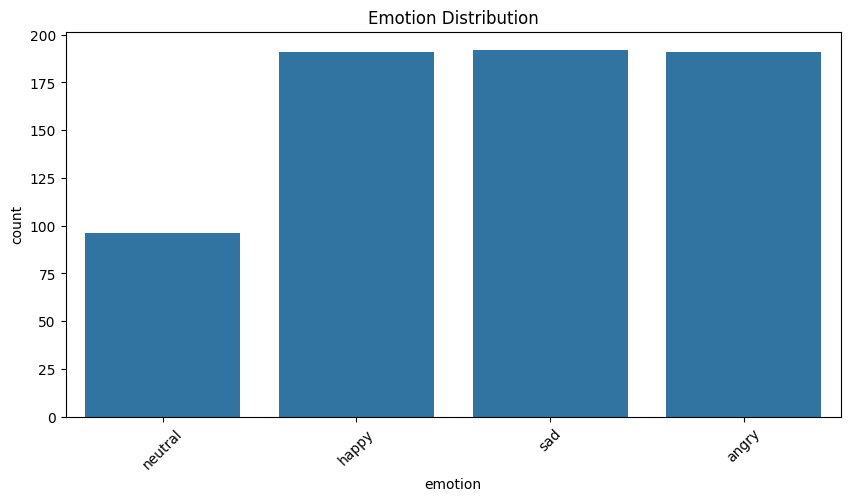

In [95]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='emotion')
plt.xticks(rotation=45)
plt.title("Emotion Distribution")
plt.show()

In [96]:
def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050, duration=2.5, offset=0.6)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.hstack((np.mean(mfcc.T, axis=0), np.std(mfcc.T, axis=0)))

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma = np.hstack((np.mean(chroma.T, axis=0), np.std(chroma.T, axis=0)))

    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel = np.hstack((np.mean(mel.T, axis=0), np.std(mel.T, axis=0)))

    zcr = librosa.feature.zero_crossing_rate(audio)
    zcr = np.mean(zcr)

    rms = librosa.feature.rms(y=audio)
    rms = np.mean(rms)

    return np.hstack((mfcc, chroma, mel, zcr, rms))

In [97]:
sample_file = df['path'][0]
features = extract_features(sample_file)

print(features.shape)

(362,)


In [98]:
X = []
y = []

for path, emotion in zip(df['path'], df['emotion']):
    feature = extract_features(path)
    X.append(feature)
    y.append(emotion)

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (670, 362)
Labels shape: (670,)


In [99]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['angry' 'happy' 'neutral' 'sad']


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(
    hidden_layer_sizes=(256,128),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

mlp_pred = mlp.predict(X_test_scaled)
mlp_accuracy=accuracy_score(y_test, mlp_pred)
print("MLP Accuracy:",mlp_accuracy)

MLP Accuracy: 0.8059701492537313


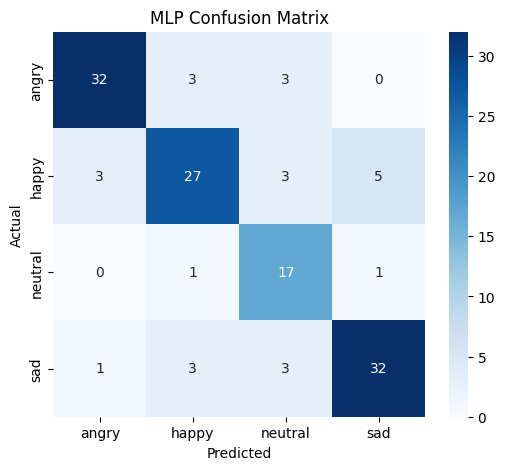

In [103]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

mlp_cm = confusion_matrix(y_test, mlp_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    mlp_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix")
plt.show()

In [104]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)
svm_accuracy=accuracy_score(y_test, svm_pred)
print("SVM Accuracy:",svm_accuracy )

SVM Accuracy: 0.7985074626865671


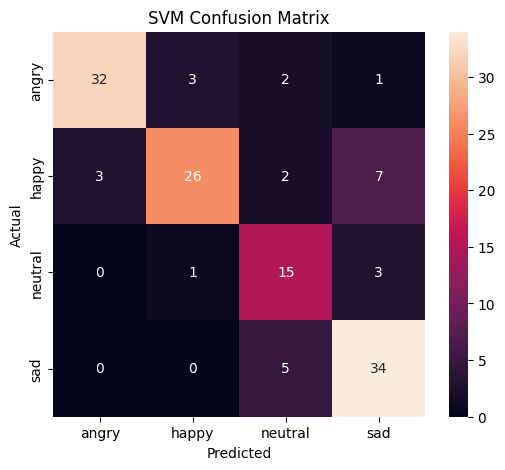

In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

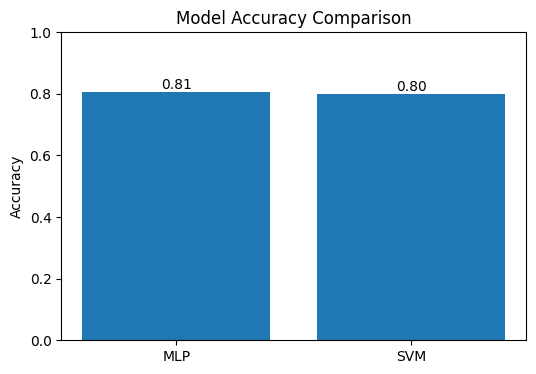

In [106]:
models = ["MLP", "SVM"]
accuracies = [mlp_accuracy, svm_accuracy]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracies)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.01,
        f"{y:.2f}",
        ha='center'
    )

plt.show()

In [108]:
new_audio = r"C:\Users\MANISHA\Downloads\03-01-03-02-02-02-24.wav"

feature = extract_features(new_audio)
feature = feature.reshape(1, -1)
feature_scaled = scaler.transform(feature)

pred = svm.predict(feature_scaled)
emotion = encoder.inverse_transform(pred)

print("Predicted Emotion:", emotion[0])

Predicted Emotion: happy
